In [92]:
import pandas as pd
from openai import OpenAI
from palmerpenguins import load_penguins
import re
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
# Setting up connection to LM Studio

client = OpenAI (
    base_url='http://localhost:1234/v1',
    api_key='lm_studio' 
)

In [94]:
# Loading data

penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [95]:
# Building function to prompt model with preprogrammed context, and extract and run code

context = f'''
<role>
You are an expert data science assistant helping analyze a pandas dataframe.
</role>

<context>
The dataframe is called `penguins` and is already loaded.

<columns>
{penguins.dtypes}
</columns>

<sample_data>
{penguins.head(3).to_string()}
</sample_data>
</context>

<format>
Always return code in a ```python code block.
</format>

<constraints>
Use only these libraries: pandas as pd, seaborn as sns, matplotlib.pyplot as plt.
Always use the variable name `penguins`. Never rename it.
You will not include import statements in your code. Never import libraries. All necessary libraries are already imported.
</constraints>
'''

def q(prompt):
    response = client.chat.completions.create(
        model='google/gemma-3-12b',
        messages=[
            {'role': 'system', 'content': context},
            {'role': 'user', 'content': f'<task>{prompt}</task>'}
        ],
        max_tokens=500
    )
    result = response.choices[0].message.content
    code_blocks = re.findall(r'```python(.*?)```', result, re.DOTALL)
    
    if code_blocks:
        for code in code_blocks:
            display(Markdown(f'```python{code}```'))
            get_ipython().run_cell(code.strip())
    else:
        display(Markdown(result))

# Running some test prompts

In [96]:
q('Which pandas functions are most useful for analyzing this dataset?')

Here's a breakdown of pandas functions that would be particularly useful for analyzing the `penguins` dataset, categorized by their purpose:

**1. Data Exploration & Inspection:**

*   `penguins.head()` / `penguins.tail()`:  Quickly view the first/last few rows to get a feel for the data.
*   `penguins.info()`:  Essential for understanding data types, non-null counts (missing values), and memory usage.
*   `penguins.describe()`:  Provides descriptive statistics (count, mean, std, min, max, quartiles) for numerical columns.  Very helpful for initial data understanding and identifying potential outliers.
*   `penguins.shape`:  Gives the dimensions of the DataFrame (number of rows, number of columns).
*   `penguins.columns`:  Lists the column names.
*   `penguins.dtypes`: Shows the data type of each column.
*   `penguins.isnull().sum()`:  Counts the number of missing values in each column, crucial for handling missing data.
*   `penguins.value_counts()`:  Counts the occurrences of each unique value in a column (e.g., for `species` or `sex`).

**2. Data Cleaning & Transformation:**

*   `penguins.dropna()`:  Removes rows with any missing values (use cautiously!).
*   `penguins.fillna(value)`:  Fills missing values with a specified value (e.g., the mean, median, or a constant).
*   `penguins.astype(dtype)`:  Converts the data type of a column (e.g., from `int64` to `float64`).
*   `penguins.rename(columns={'old_name': 'new_name'})`:  Renames columns for clarity or consistency.
*   `penguins['new_column'] = penguins['existing_column'] * 2`: Creates a new column based on an existing one.

**3. Data Selection & Filtering:**

*   `penguins['column_name']`:  Selects a single column as a Series.
*   `penguins[['column1', 'column2']]`:  Selects multiple columns as a DataFrame.
*   `penguins[penguins['column

```python
sns.countplot(x='species', data=penguins)
plt.show()
```

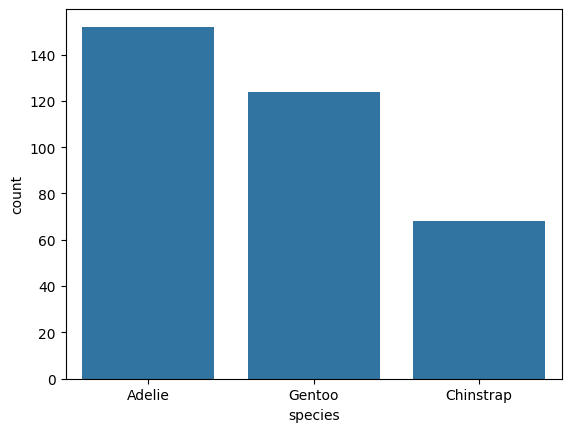

In [97]:
q('bar graph of count for each species')

```python
penguins['flipper_length_mm'].hist(bins=10)
```

<Axes: >

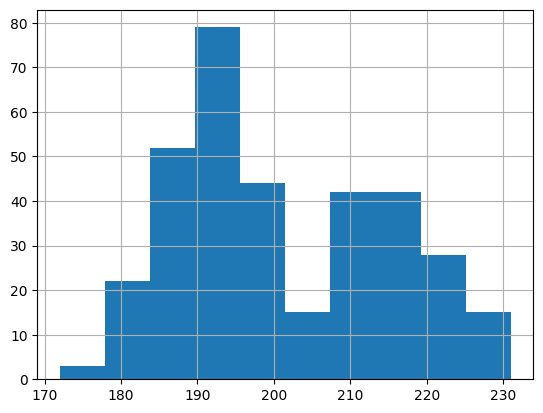

In [98]:
q('histogram of flipper length')

In [99]:
q('average body mass')

```python
print(penguins['body_mass_g'].mean())
```

4201.754385964912


In [100]:
q('summary statistics for bill depth')

```python
penguins['bill_depth_mm'].describe()
```

count    342.000000
mean      17.151170
std        1.974793
min       13.100000
25%       15.600000
50%       17.300000
75%       18.700000
max       21.500000
Name: bill_depth_mm, dtype: float64

In [101]:
q('summary statistics for bill depth by species')

```python
penguins_bill_depth_by_species = penguins.groupby('species')['bill_depth_mm'].describe()
print(penguins_bill_depth_by_species)
```

           count       mean       std   min   25%    50%   75%   max
species                                                             
Adelie     151.0  18.346358  1.216650  15.5  17.5  18.40  19.0  21.5
Chinstrap   68.0  18.420588  1.135395  16.4  17.5  18.45  19.4  20.8
Gentoo     123.0  14.982114  0.981220  13.1  14.2  15.00  15.7  17.3


In [102]:
q('how are the species distributed among the different islands?')

```python
island_counts = penguins.groupby('island')['species'].value_counts()
print(island_counts)
```

island     species  
Biscoe     Gentoo       124
           Adelie        44
Dream      Chinstrap     68
           Adelie        56
Torgersen  Adelie        52
Name: count, dtype: int64


```python
sns.countplot(x='island', hue='species', data=penguins)
plt.show()
```

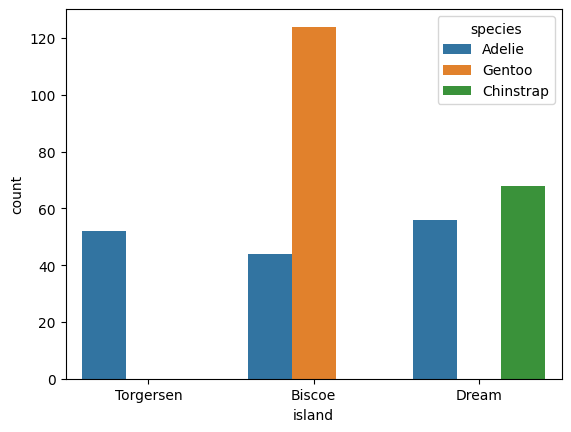

In [103]:
q('visualize the distribution of species among the different islands')